# Options Strategy Recommendation and Optimisation System
## Notebook 7 - End-to-End System Demo

This notebook is the presentation-facing demonstration of the complete intelligent reasoning pipeline. A user supplies only a stock ticker and a bullish/bearish outlook. The notebook loads the validated outputs from Notebooks 1-6 and presents one exact, explainable, risk-bounded options strategy recommendation.

## Demo flow

1. Capture the user's ticker and directional outlook.
2. Verify that every upstream stage is ready and belongs to the same request.
3. Summarise the current market and reasoning state.
4. Present the GA-selected strategy family, expiry, exact option legs, cost, risk and expectancy.
5. Visualise the expiration payoff and expected-move scenarios.
6. Show alternative candidates and quantitative evaluation evidence.
7. Export a compact payload for the later `app.py` interface.

The system is decision support, not trading advice. It does not claim a full historical-options backtest.

## 1. Environment setup

If required, install packages once with: `pip install pandas numpy matplotlib`.

In [4]:
from __future__ import annotations

import json
import math
import re
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = lambda text: text
    display = print

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | numpy: {np.__version__}")

Python: 3.9.23 | pandas: 2.3.2 | numpy: 1.26.4


## 2. User input

These are the only two required user-level inputs. Run Notebooks 1-6 with the same values before running this demo.

In [6]:
TICKER = "CRM"
OUTLOOK = "bullish"  # allowed: bullish, bearish


In [7]:
NOTEBOOK2_ROOT = Path("outputs/notebook_02")
NOTEBOOK3_ROOT = Path("outputs/notebook_03")
NOTEBOOK5_ROOT = Path("outputs/notebook_05")
NOTEBOOK6_ROOT = Path("outputs/notebook_06")
NOTEBOOK7_ROOT = Path("outputs/notebook_07")

TOP_ALTERNATIVES = 5
PAYOFF_GRID_POINTS = 501

def validate_user_input(ticker: str, outlook: str) -> tuple[str, str]:
    ticker = ticker.strip().upper().replace(".", "-")
    outlook = outlook.strip().lower()
    if not ticker or not re.fullmatch(r"[A-Z0-9^=-]{1,15}", ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    if outlook not in {"bullish", "bearish"}:
        raise ValueError("OUTLOOK must be either 'bullish' or 'bearish'.")
    return ticker, outlook

ticker, outlook = validate_user_input(TICKER, OUTLOOK)
run_name = f"{ticker}_{outlook}"
expected_request = {"ticker": ticker, "outlook": outlook}
NOTEBOOK2_DIR = NOTEBOOK2_ROOT / ticker
NOTEBOOK3_DIR = NOTEBOOK3_ROOT / ticker / outlook
NOTEBOOK5_DIR = NOTEBOOK5_ROOT / ticker / outlook
NOTEBOOK6_DIR = NOTEBOOK6_ROOT / ticker / outlook
OUTPUT_DIR = NOTEBOOK7_ROOT / ticker / outlook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

input_paths = {
    "feature_snapshot": NOTEBOOK2_DIR / "feature_snapshot.json",
    "expiry_features": NOTEBOOK2_DIR / "expiry_features.csv",
    "ranked_strategies": NOTEBOOK3_DIR / "ranked_strategy_families.csv",
    "reasoning_trace": NOTEBOOK3_DIR / "reasoning_trace.json",
    "ranked_recommendations": NOTEBOOK5_DIR / "ga_ranked_recommendations.csv",
    "best_strategy": NOTEBOOK5_DIR / "ga_best_strategy.json",
    "pipeline_quality_audit": NOTEBOOK6_DIR / "pipeline_quality_audit.csv",
    "method_comparison": NOTEBOOK6_DIR / "method_comparison.csv",
    "weight_sensitivity": NOTEBOOK6_DIR / "fitness_weight_sensitivity.csv",
    "evaluation_limitations": NOTEBOOK6_DIR / "evaluation_limitations.csv",
    "evaluation_quality": NOTEBOOK6_DIR / "evaluation_quality_report.csv",
    "evaluation_summary": NOTEBOOK6_DIR / "evaluation_summary.json",
}
input_paths


{'feature_snapshot': WindowsPath('outputs/notebook_02/CRM/feature_snapshot.json'),
 'expiry_features': WindowsPath('outputs/notebook_02/CRM/expiry_features.csv'),
 'ranked_strategies': WindowsPath('outputs/notebook_03/CRM/bullish/ranked_strategy_families.csv'),
 'reasoning_trace': WindowsPath('outputs/notebook_03/CRM/bullish/reasoning_trace.json'),
 'ranked_recommendations': WindowsPath('outputs/notebook_05/CRM/bullish/ga_ranked_recommendations.csv'),
 'best_strategy': WindowsPath('outputs/notebook_05/CRM/bullish/ga_best_strategy.json'),
 'pipeline_quality_audit': WindowsPath('outputs/notebook_06/CRM/bullish/pipeline_quality_audit.csv'),
 'method_comparison': WindowsPath('outputs/notebook_06/CRM/bullish/method_comparison.csv'),
 'weight_sensitivity': WindowsPath('outputs/notebook_06/CRM/bullish/fitness_weight_sensitivity.csv'),
 'evaluation_limitations': WindowsPath('outputs/notebook_06/CRM/bullish/evaluation_limitations.csv'),
 'evaluation_quality': WindowsPath('outputs/notebook_06/CR

In [8]:
missing_files = [str(path) for path in input_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required demo inputs were not found. Run Notebooks 1-6 with the same ticker/outlook first. Missing: "
        + ", ".join(missing_files)
    )

expiry_features = pd.read_csv(input_paths["expiry_features"])
ranked_strategies = pd.read_csv(input_paths["ranked_strategies"])
ranked_recommendations = pd.read_csv(input_paths["ranked_recommendations"])
pipeline_quality_audit = pd.read_csv(input_paths["pipeline_quality_audit"])
method_comparison = pd.read_csv(input_paths["method_comparison"])
weight_sensitivity = pd.read_csv(input_paths["weight_sensitivity"])
evaluation_limitations = pd.read_csv(input_paths["evaluation_limitations"])
evaluation_quality = pd.read_csv(input_paths["evaluation_quality"])

with input_paths["feature_snapshot"].open("r", encoding="utf-8") as file:
    feature_snapshot = json.load(file)
with input_paths["reasoning_trace"].open("r", encoding="utf-8") as file:
    reasoning_trace = json.load(file)
with input_paths["best_strategy"].open("r", encoding="utf-8") as file:
    best_strategy = json.load(file)
with input_paths["evaluation_summary"].open("r", encoding="utf-8") as file:
    evaluation_summary = json.load(file)

if feature_snapshot.get("request") != {"ticker": ticker}:
    raise ValueError("Notebook 2 snapshot does not match the configured ticker.")
pair_request_records = [
    reasoning_trace.get("request"), best_strategy.get("request"),
    evaluation_summary.get("request"),
]
if any(record != expected_request for record in pair_request_records):
    raise ValueError("At least one directional upstream output does not match the configured ticker/outlook.")
if any(frame.empty for frame in [expiry_features, ranked_strategies, ranked_recommendations, pipeline_quality_audit, method_comparison, evaluation_quality]):
    raise ValueError("At least one required demo table is empty.")

def normalise_passed(values: pd.Series) -> pd.Series:
    return values.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})

pipeline_quality_audit["passed"] = normalise_passed(pipeline_quality_audit["passed"])
evaluation_quality["passed"] = normalise_passed(evaluation_quality["passed"])

numeric_columns = [
    "rank", "reasoning_score", "strategy_rank", "dte", "long_strike", "short_strike",
    "long_entry_price", "short_entry_price", "short_strike_index", "entry_cashflow_per_share",
    "net_premium_per_share", "max_profit", "max_loss", "breakeven", "reward_to_risk",
    "liquidity_score", "probability_of_profit", "expected_profit", "p05_profit", "p95_profit",
    "estimated_transaction_cost", "adjusted_expected_profit", "adjusted_max_loss",
    "net_expected_return_on_risk", "fitness_score", "fitness_rank",
]
for column in numeric_columns:
    if column in ranked_recommendations.columns:
        ranked_recommendations[column] = pd.to_numeric(ranked_recommendations[column], errors="coerce")

best_match = ranked_recommendations.loc[
    ranked_recommendations["candidate_id"].astype(str).eq(str(best_strategy["candidate_id"]))
]
if len(best_match) != 1:
    raise KeyError("Notebook 5's best candidate must appear exactly once in the ranked recommendation table.")
recommended = best_match.iloc[0].copy()
print(f"Demo inputs loaded for {ticker} / {outlook}. Candidate: {recommended['candidate_id']}")

Demo inputs loaded for CRM / bullish. Candidate: bull_call_spread|2026-10-16|L2|S10


## 3. Pipeline readiness

,stage,checks,passed_checks,pass_rate,ready
0,Notebook 1 - Data,10,10,1.0000,True
1,Notebook 2 - Features,9,9,1.0000,True
2,Notebook 3 - Reasoning,10,10,1.0000,True
3,Notebook 4 - Payoffs,10,10,1.0000,True
4,Notebook 5 - Optimisation,14,14,1.0000,True
5,Notebook 6 - Evaluation,21,21,1.0000,True


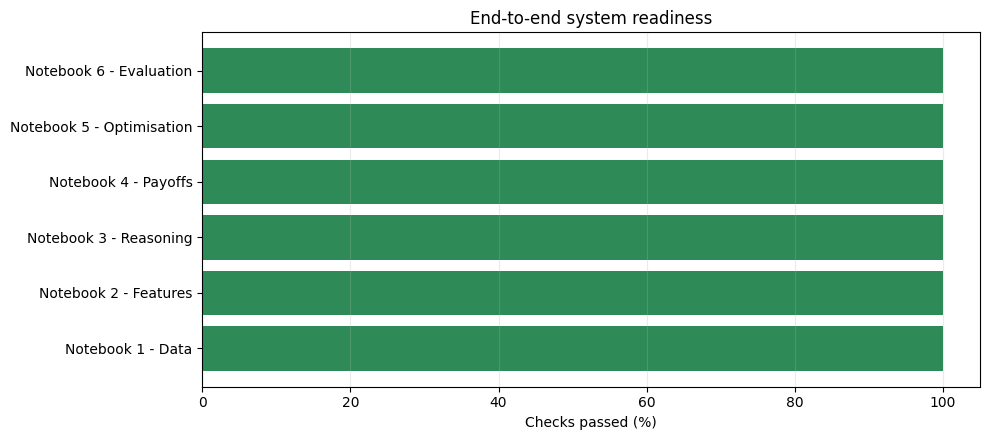

In [10]:
pipeline_status = pipeline_quality_audit.groupby("stage", as_index=False).agg(
    checks=("check", "count"),
    passed_checks=("passed", "sum"),
)
pipeline_status["pass_rate"] = pipeline_status["passed_checks"] / pipeline_status["checks"]
pipeline_status["ready"] = pipeline_status["passed_checks"].eq(pipeline_status["checks"])

evaluation_stage = pd.DataFrame([{
    "stage": "Notebook 6 - Evaluation",
    "checks": len(evaluation_quality),
    "passed_checks": int(evaluation_quality["passed"].sum()),
    "pass_rate": float(evaluation_quality["passed"].mean()),
    "ready": bool(evaluation_quality["passed"].all()),
}])
pipeline_status = pd.concat([pipeline_status, evaluation_stage], ignore_index=True)
display(pipeline_status)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = np.where(pipeline_status["ready"], "#2E8B57", "#C23B22")
ax.barh(pipeline_status["stage"], pipeline_status["pass_rate"] * 100, color=colors)
ax.set_xlim(0, 105)
ax.set_title("End-to-end system readiness")
ax.set_xlabel("Checks passed (%)")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Market and reasoning context

In [12]:
underlying = feature_snapshot["underlying_features"]
spot_price = float(underlying["current_price"])
recommended_expiry = pd.Timestamp(recommended["expiry"]).strftime("%Y-%m-%d")
expiry_features["expiry"] = pd.to_datetime(expiry_features["expiry"]).dt.strftime("%Y-%m-%d")
expiry_match = expiry_features.loc[expiry_features["expiry"].eq(recommended_expiry)]
if expiry_match.empty:
    raise KeyError("The recommended expiry is absent from Notebook 2's expiry feature table.")
expiry_state = expiry_match.iloc[0]

strategy_family_match = ranked_strategies.loc[
    ranked_strategies["strategy_id"].astype(str).eq(str(recommended["strategy_type"]))
]
if strategy_family_match.empty:
    raise KeyError("The recommended strategy family is absent from Notebook 3's ranking.")
strategy_family = strategy_family_match.iloc[0]

market_summary = pd.DataFrame([
    ("Ticker", ticker),
    ("User outlook", outlook.title()),
    ("Current price", f"${spot_price:,.2f}"),
    ("Trend", str(underlying.get("trend_label", "unknown")).replace("_", " ").title()),
    ("Trend score", underlying.get("trend_score")),
    ("Outlook alignment", str(strategy_family.get("outlook_alignment", "unknown")).title()),
    ("20-day historical volatility", f"{float(underlying.get('historical_vol_20', np.nan)):.1%}"),
    ("Implied-volatility regime", str(expiry_state["volatility_regime"]).replace("_", " ").title()),
    ("Expected move to expiry", f"+/- ${float(expiry_state['expected_move']):,.2f} ({float(expiry_state['expected_move_pct']):.1%})"),
    ("Recommended DTE", int(recommended["dte"])),
], columns=["item", "value"])
display(market_summary)

,item,value
0,Ticker,CRM
1,User outlook,Bullish
2,Current price,$252.05
3,Trend,Strong Bullish
4,Trend score,100.0000
5,Outlook alignment,Aligned
6,20-day historical volatility,79.1%
7,Implied-volatility regime,Low Iv Relative To Hv
8,Expected move to expiry,+/- $36.75 (14.6%)
9,Recommended DTE,47


## 5. Exact trade construction

In [14]:
trade_leg_rows = [{
    "leg": 1,
    "action": "BUY",
    "quantity": 1,
    "option_type": str(recommended["option_type"]).upper(),
    "contract_symbol": recommended["long_symbol"],
    "expiry": recommended_expiry,
    "strike": float(recommended["long_strike"]),
    "entry_price_per_share": float(recommended["long_entry_price"]),
    "cashflow_per_share": -float(recommended["long_entry_price"]),
}]
if int(recommended["short_strike_index"]) >= 0:
    trade_leg_rows.append({
        "leg": 2,
        "action": "SELL",
        "quantity": 1,
        "option_type": str(recommended["option_type"]).upper(),
        "contract_symbol": recommended["short_symbol"],
        "expiry": recommended_expiry,
        "strike": float(recommended["short_strike"]),
        "entry_price_per_share": float(recommended["short_entry_price"]),
        "cashflow_per_share": float(recommended["short_entry_price"]),
    })

trade_legs = pd.DataFrame(trade_leg_rows)
trade_legs["cashflow_per_contract"] = trade_legs["cashflow_per_share"] * 100
calculated_entry_cashflow = float(trade_legs["cashflow_per_share"].sum())
entry_type = "Credit" if calculated_entry_cashflow > 0 else "Debit"
entry_amount = abs(calculated_entry_cashflow) * 100
display(trade_legs)
print(
    f"{entry_type}: ${entry_amount:,.2f} before estimated explicit transaction cost of "
    f"${float(recommended['estimated_transaction_cost']):,.2f}."
)

,leg,action,quantity,option_type,contract_symbol,expiry,strike,entry_price_per_share,cashflow_per_share,cashflow_per_contract
0,1,BUY,1,CALL,CRM261016C00170000,2026-10-16,170.0000,88.7500,-88.7500,"-8,875.0000"
1,2,SELL,1,CALL,CRM261016C00230000,2026-10-16,230.0000,31.0000,31.0000,"3,100.0000"


Debit: $5,775.00 before estimated explicit transaction cost of $122.47.


## 6. Expiration payoff visualisation

The curve uses Notebook 4's conservative entry cashflow and subtracts Notebook 5's explicit transaction-cost estimate. It is an expiration payoff, not a forecast of the path before expiry.

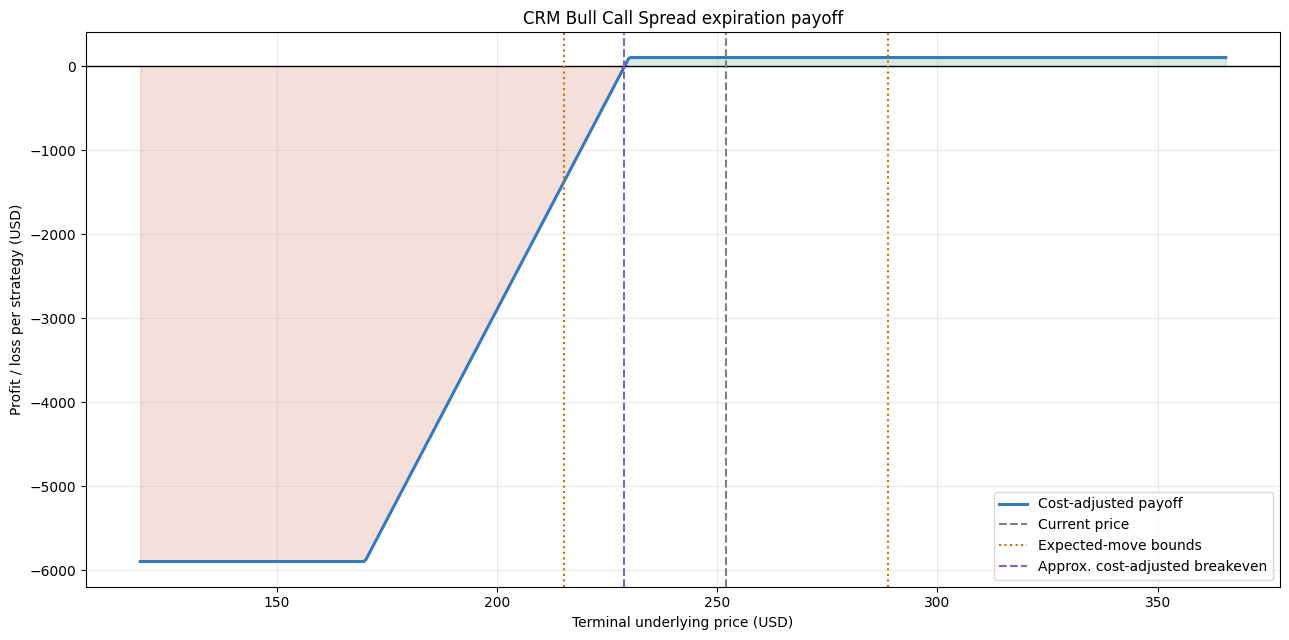

In [16]:
def intrinsic_value(stock_prices: np.ndarray, strike: float, option_type: str) -> np.ndarray:
    return np.maximum(stock_prices - strike, 0) if option_type == "call" else np.maximum(strike - stock_prices, 0)

def payoff_at_expiry(stock_prices: np.ndarray) -> np.ndarray:
    pnl_per_share = intrinsic_value(stock_prices, float(recommended["long_strike"]), str(recommended["option_type"]))
    if int(recommended["short_strike_index"]) >= 0:
        pnl_per_share -= intrinsic_value(stock_prices, float(recommended["short_strike"]), str(recommended["option_type"]))
    return (
        pnl_per_share * 100
        + float(recommended["entry_cashflow_per_share"]) * 100
        - float(recommended["estimated_transaction_cost"])
    )

expected_lower = float(expiry_state["expected_lower_price"])
expected_upper = float(expiry_state["expected_upper_price"])
grid_low = max(0.01, min(spot_price * 0.55, expected_lower * 0.80, float(recommended["long_strike"]) * 0.70))
grid_high = max(spot_price * 1.45, expected_upper * 1.20, float(recommended["long_strike"]) * 1.30)
terminal_price_grid = np.linspace(grid_low, grid_high, PAYOFF_GRID_POINTS)
payoff_curve = pd.DataFrame({
    "terminal_stock_price": terminal_price_grid,
    "profit_loss": payoff_at_expiry(terminal_price_grid),
})
adjusted_breakeven_approx = float(
    payoff_curve.loc[payoff_curve["profit_loss"].abs().idxmin(), "terminal_stock_price"]
)

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(payoff_curve["terminal_stock_price"], payoff_curve["profit_loss"], color="#357ABD", linewidth=2.2, label="Cost-adjusted payoff")
ax.fill_between(payoff_curve["terminal_stock_price"], payoff_curve["profit_loss"], 0, where=payoff_curve["profit_loss"].ge(0), color="#2E8B57", alpha=0.18)
ax.fill_between(payoff_curve["terminal_stock_price"], payoff_curve["profit_loss"], 0, where=payoff_curve["profit_loss"].lt(0), color="#C23B22", alpha=0.16)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(spot_price, color="grey", linestyle="--", label="Current price")
ax.axvline(expected_lower, color="#C76E00", linestyle=":", label="Expected-move bounds")
ax.axvline(expected_upper, color="#C76E00", linestyle=":")
ax.axvline(adjusted_breakeven_approx, color="#8A5FBF", linestyle="--", label="Approx. cost-adjusted breakeven")
ax.set_title(f"{ticker} {recommended['strategy_name']} expiration payoff")
ax.set_xlabel("Terminal underlying price (USD)")
ax.set_ylabel("Profit / loss per strategy (USD)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
scenario_levels = {
    "Expected lower bound": expected_lower,
    "Current price": spot_price,
    "Analytical breakeven before explicit cost": float(recommended["breakeven"]),
    "Approx. cost-adjusted breakeven": adjusted_breakeven_approx,
    "Expected upper bound": expected_upper,
}
payoff_scenarios = pd.DataFrame([
    {"scenario": name, "terminal_stock_price": price, "profit_loss": float(payoff_at_expiry(np.array([price]))[0])}
    for name, price in scenario_levels.items()
]).drop_duplicates("terminal_stock_price").sort_values("terminal_stock_price").reset_index(drop=True)
display(payoff_scenarios)

,scenario,terminal_stock_price,profit_loss
0,Expected lower bound,215.3030,"-1,367.1668"
1,Analytical breakeven before explicit cost,227.7500,-122.4700
2,Approx. cost-adjusted breakeven,228.9267,-4.7963
3,Current price,252.0500,102.5300
4,Expected upper bound,288.7970,102.5300


## 7. Recommendation card

In [19]:
def money_or_unlimited(value: Any) -> str:
    try:
        numeric = float(value)
        return f"${numeric:,.2f}" if math.isfinite(numeric) else "Unlimited"
    except (TypeError, ValueError):
        return "Not available"

ga_evaluation = method_comparison.loc[method_comparison["method"].eq("Rule + GA")]
if ga_evaluation.empty:
    raise KeyError("Notebook 6 method comparison has no 'Rule + GA' row.")
ga_evaluation = ga_evaluation.iloc[0]

knowledge_explanation = str(strategy_family.get("explanation", "The strategy family supports the user's direction and current volatility regime."))
optimisation_explanation = str(recommended.get("recommendation_explanation", best_strategy.get("explanation", "Selected by the cost-adjusted GA fitness function.")))

recommendation_markdown = f'''
### Final recommendation: {recommended['strategy_name']}

**User request:** {ticker} / {outlook.title()}  
**Expiry:** {recommended_expiry} ({int(recommended['dte'])} DTE)  
**Entry:** {entry_type} of ${entry_amount:,.2f} before estimated explicit cost  
**Maximum profit:** {money_or_unlimited(recommended['max_profit'])} before explicit cost  
**Maximum loss:** ${float(recommended['adjusted_max_loss']):,.2f}, including estimated explicit cost  
**Probability of profit:** {float(recommended['probability_of_profit']):.1%}  
**Cost-adjusted expected profit:** ${float(recommended['adjusted_expected_profit']):,.2f}  
**Expected return on maximum risk:** {float(recommended['net_expected_return_on_risk']):.1%}  
**Liquidity score:** {float(recommended['liquidity_score']):.1f}/100  
**GA fitness:** {float(recommended['fitness_score']):.2f}/100  
**Historical-return stress probability of profit:** {float(ga_evaluation['stress_probability_of_profit']):.1%}

**Why this strategy family:** {knowledge_explanation}

**Why these exact contracts:** {optimisation_explanation}

> Decision support only. Current-chain modelling cannot guarantee fills or future performance and is not a full historical-options backtest.
'''
display(Markdown(recommendation_markdown))


### Final recommendation: Bull Call Spread

**User request:** CRM / Bullish  
**Expiry:** 2026-10-16 (47 DTE)  
**Entry:** Debit of $5,775.00 before estimated explicit cost  
**Maximum profit:** $225.00 before explicit cost  
**Maximum loss:** $5,897.47, including estimated explicit cost  
**Probability of profit:** 80.3%  
**Cost-adjusted expected profit:** $-288.23  
**Expected return on maximum risk:** -4.9%  
**Liquidity score:** 60.7/100  
**GA fitness:** 74.04/100  
**Historical-return stress probability of profit:** 69.4%

**Why this strategy family:** Direction rule: Bull Call Spread supports the user's bullish outlook. | low_iv_relative_to_hv favours debit structures. | Trend alignment is aligned (+10 points). | Median expiry liquidity is 52.3/100 (+5 points).

**Why these exact contracts:** Selected for strong probability of profit and downside protection; estimated explicit cost $122.47, net expected profit $-288.23, probability of profit 80.3%.

> Decision support only. Current-chain modelling cannot guarantee fills or future performance and is not a full historical-options backtest.


## 8. Alternatives and experimental evidence

In [21]:
alternatives = ranked_recommendations.loc[
    ~ranked_recommendations["candidate_id"].astype(str).eq(str(recommended["candidate_id"]))
].sort_values("fitness_rank").head(TOP_ALTERNATIVES).copy()
alternative_columns = [
    "fitness_rank", "candidate_id", "strategy_name", "expiry", "long_strike", "short_strike",
    "adjusted_expected_profit", "probability_of_profit", "adjusted_max_loss", "liquidity_score", "fitness_score",
]
display(alternatives[alternative_columns])

evidence_columns = [
    "method", "adjusted_expected_profit", "probability_of_profit", "net_expected_return_on_risk",
    "adjusted_max_loss", "liquidity_score", "fitness_score", "stress_expected_profit",
    "stress_probability_of_profit", "valid_recommendation_rate",
]
available_evidence_columns = [column for column in evidence_columns if column in method_comparison.columns]
display(method_comparison[available_evidence_columns])

,fitness_rank,candidate_id,strategy_name,expiry,long_strike,short_strike,adjusted_expected_profit,probability_of_profit,adjusted_max_loss,liquidity_score,fitness_score
1,2,bull_call_spread|2026-10-16|L2|S12,Bull Call Spread,2026-10-16,170.0000,250.0000,-256.3313,0.6751,"7,238.9200",64.3478,68.8785
2,3,bull_call_spread|2026-10-16|L1|S10,Bull Call Spread,2026-10-16,165.0000,230.0000,-284.0034,0.8034,"6,392.3700",47.8261,66.0969
3,4,bull_call_spread|2026-10-16|L2|S11,Bull Call Spread,2026-10-16,170.0000,240.0000,-289.4021,0.7349,"6,635.0200",55.2174,65.9099
4,5,bull_call_spread|2026-10-16|L5|S10,Bull Call Spread,2026-10-16,185.0000,230.0000,-294.4388,0.8002,"4,412.7700",56.0870,65.5116
5,6,bull_call_spread|2026-10-16|L2|S15,Bull Call Spread,2026-10-16,170.0000,280.0000,-108.5661,0.5527,"8,367.5200",64.1304,64.2059


,method,adjusted_expected_profit,probability_of_profit,net_expected_return_on_risk,adjusted_max_loss,liquidity_score,fitness_score,stress_expected_profit,stress_probability_of_profit,valid_recommendation_rate
0,Random chromosome,-103.0658,0.5874,-0.0320,"4,580.0407",52.3333,51.4803,-867.0242,0.3867,0.1864
1,Fixed-ATM baseline,52.6693,0.4107,0.0320,"1,647.2900",42.1739,47.9148,-768.3305,0.2101,1.0000
2,Rule-only baseline,47.5940,0.3092,0.0677,702.9400,42.1739,50.4286,-348.9504,0.1363,1.0000
3,Rule + GA,-288.2271,0.8026,-0.0489,"5,897.4700",60.6522,74.0390,-601.1597,0.6939,1.0000
4,Exhaustive oracle,-288.2271,0.8026,-0.0489,"5,897.4700",60.6522,74.0390,-601.1597,0.6939,1.0000


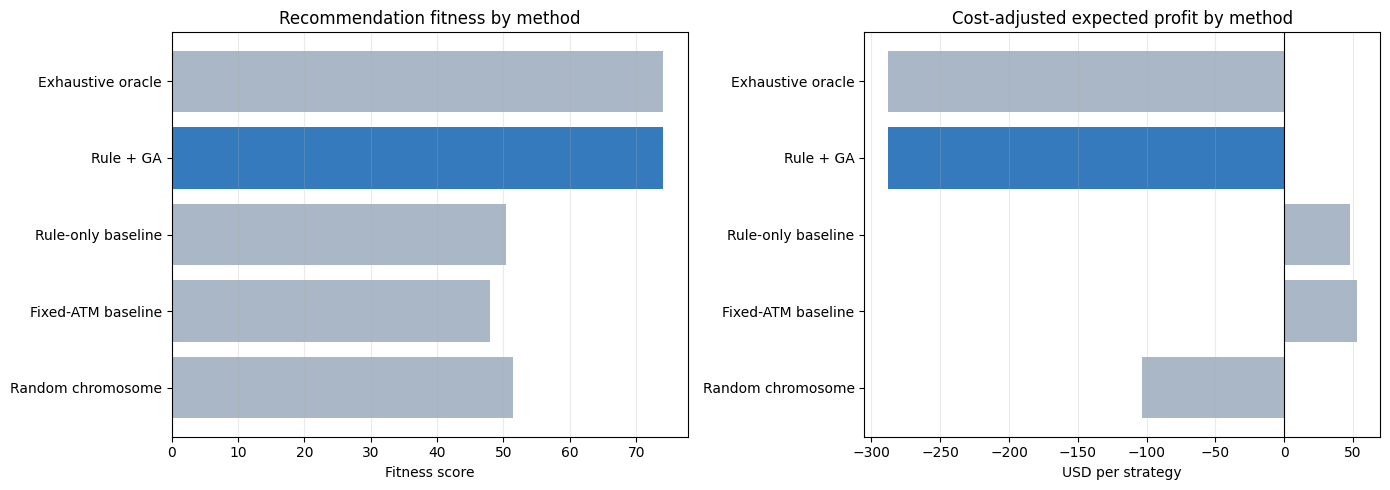

#### Fitness-weight sensitivity

,profile,candidate_id,strategy_type,profile_fitness_score,adjusted_expected_profit,probability_of_profit,adjusted_max_loss,liquidity_score,top_k_overlap_with_balanced
0,Balanced (Notebook 5),bull_call_spread|2026-10-16|L2|S10,bull_call_spread,74.0390,-288.2271,0.8026,"5,897.4700",60.6522,1.0000
1,Return focused,long_call|2026-10-16|L12|S-1,long_call,72.9872,160.2415,0.3842,"1,910.2600",64.3478,0.3333
2,Conservative,bull_call_spread|2026-10-16|L2|S10,bull_call_spread,77.6877,-288.2271,0.8026,"5,897.4700",60.6522,0.5385
3,Liquidity focused,bull_call_spread|2026-10-16|L2|S10,bull_call_spread,76.7536,-288.2271,0.8026,"5,897.4700",60.6522,0.3333


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#357ABD" if method == "Rule + GA" else "#A9B7C6" for method in method_comparison["method"]]
axes[0].barh(method_comparison["method"], method_comparison["fitness_score"], color=colors)
axes[0].set_title("Recommendation fitness by method")
axes[0].set_xlabel("Fitness score")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(method_comparison["method"], method_comparison["adjusted_expected_profit"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Cost-adjusted expected profit by method")
axes[1].set_xlabel("USD per strategy")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(Markdown("#### Fitness-weight sensitivity"))
display(weight_sensitivity)

## 9. Known limitations

In [24]:
display(evaluation_limitations)
print(
    "The recommendation should be refreshed immediately before any decision because price, implied volatility, "
    "bid/ask spread, open interest and volume may have changed."
)

,limitation,impact
0,Historical option data,No dependable expired-chain bid/ask archive; this notebook does not claim a historical options backtest.
1,Pricing,Current ask-for-buy and bid-for-sell assumptions may still differ from realised fills.
2,Monte Carlo model,"Geometric-Brownian terminal prices simplify volatility dynamics, jumps, skew, and event risk."
3,Historical stress,"Reuses current strikes and premiums with past underlying returns; it is a stress simulation, not a trade replay."
4,Exercise and assignment,"Early exercise, assignment, dividends, pin risk, and margin changes are excluded."
5,Costs,"Commission, fee, and slippage parameters are estimates and should be replaced with broker-specific values."
6,Single-position MVP,Results evaluate one strategy of one contract; portfolio exposure and cross-position constraints are excluded.
7,User outlook,Bullish/bearish input is treated as a user belief and is not itself predicted or guaranteed by the system.
8,Live-chain instability,"Contract availability, implied volatility, spreads, and volume can change between data retrieval and execution."


The recommendation should be refreshed immediately before any decision because price, implied volatility, bid/ask spread, open interest and volume may have changed.


## 10. Demo quality checks

In [26]:
directional_strategies = (
    {"bull_call_spread", "bull_put_spread", "long_call"}
    if outlook == "bullish"
    else {"bear_put_spread", "bear_call_spread", "long_put"}
)
cashflow_matches = math.isclose(
    calculated_entry_cashflow,
    float(recommended["entry_cashflow_per_share"]),
    abs_tol=1e-8,
)

quality_checks = {
    "all_requests_match_user_input": (
    feature_snapshot.get("request") == {"ticker": ticker}
        and all(
            record == expected_request
            for record in pair_request_records
        )
    ),
    "all_pipeline_stages_are_ready": bool(pipeline_status["ready"].all()),
    "notebook5_best_candidate_is_unique": len(best_match) == 1,
    "notebook5_json_matches_candidate": str(best_strategy["candidate_id"]) == str(recommended["candidate_id"]),
    "notebook6_evaluation_matches_candidate": str(evaluation_summary["ga_candidate_id"]) == str(recommended["candidate_id"]),
    "recommendation_matches_user_outlook": str(recommended["strategy_type"]) in directional_strategies,
    "trade_has_one_or_two_legs": len(trade_legs) in {1, 2},
    "trade_cashflow_matches_payoff_engine": cashflow_matches,
    "all_legs_share_expiry_and_type": trade_legs["expiry"].nunique() == 1 and trade_legs["option_type"].nunique() == 1,
    "spot_and_expected_move_are_positive": spot_price > 0 and float(expiry_state["expected_move"]) > 0,
    "recommended_expiry_is_available": not expiry_match.empty,
    "probability_of_profit_is_bounded": 0 <= float(recommended["probability_of_profit"]) <= 1,
    "adjusted_maximum_loss_is_positive": float(recommended["adjusted_max_loss"]) > 0,
    "payoff_curve_contains_profit_and_loss": bool(payoff_curve["profit_loss"].min() < 0 < payoff_curve["profit_loss"].max()),
    "knowledge_explanation_is_present": len(knowledge_explanation.strip()) >= 20,
    "optimisation_explanation_is_present": len(optimisation_explanation.strip()) >= 20,
    "alternatives_are_available": len(alternatives) >= 1,
    "evaluation_does_not_claim_full_backtest": evaluation_summary.get("full_historical_options_backtest_claimed") is False,
}
demo_quality_report = pd.DataFrame([{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()])
display(demo_quality_report)
failed = demo_quality_report.loc[~demo_quality_report["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Notebook 7 demo quality checks failed: {failed}")
print("All Notebook 7 demo quality checks passed.")

,check,passed
0,all_requests_match_user_input,True
1,all_pipeline_stages_are_ready,True
2,notebook5_best_candidate_is_unique,True
3,notebook5_json_matches_candidate,True
4,notebook6_evaluation_matches_candidate,True
5,recommendation_matches_user_outlook,True
6,trade_has_one_or_two_legs,True
7,trade_cashflow_matches_payoff_engine,True
8,all_legs_share_expiry_and_type,True
9,spot_and_expected_move_are_positive,True


All Notebook 7 demo quality checks passed.


## 11. Export the demo payload for `app.py`

In [28]:
def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        numeric = float(value)
        return numeric if math.isfinite(numeric) else None
    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()
    if value is None or (not isinstance(value, (dict, list, tuple)) and pd.isna(value)):
        return None
    return value

demo_recommendation = json_safe({
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": expected_request,
    "market": {
        "current_price": spot_price,
        "trend_label": underlying.get("trend_label"),
        "trend_score": underlying.get("trend_score"),
        "outlook_alignment": strategy_family.get("outlook_alignment"),
        "historical_volatility_20": underlying.get("historical_vol_20"),
        "volatility_regime": expiry_state["volatility_regime"],
        "expected_move": expiry_state["expected_move"],
        "expected_move_pct": expiry_state["expected_move_pct"],
        "expected_lower_price": expected_lower,
        "expected_upper_price": expected_upper,
    },
    "recommendation": {
        "candidate_id": recommended["candidate_id"],
        "strategy_type": recommended["strategy_type"],
        "strategy_name": recommended["strategy_name"],
        "expiry": recommended_expiry,
        "dte": recommended["dte"],
        "entry_type": entry_type.lower(),
        "entry_amount_before_explicit_cost": entry_amount,
        "estimated_transaction_cost": recommended["estimated_transaction_cost"],
        "max_profit_before_explicit_cost": recommended["max_profit"],
        "max_profit_label": money_or_unlimited(recommended["max_profit"]),
        "adjusted_max_loss": recommended["adjusted_max_loss"],
        "analytical_breakeven_before_explicit_cost": recommended["breakeven"],
        "approximate_cost_adjusted_breakeven": adjusted_breakeven_approx,
        "probability_of_profit": recommended["probability_of_profit"],
        "adjusted_expected_profit": recommended["adjusted_expected_profit"],
        "net_expected_return_on_risk": recommended["net_expected_return_on_risk"],
        "liquidity_score": recommended["liquidity_score"],
        "fitness_score": recommended["fitness_score"],
        "knowledge_explanation": knowledge_explanation,
        "optimisation_explanation": optimisation_explanation,
    },
    "trade_legs": trade_legs.to_dict(orient="records"),
    "evaluation": {
        "historical_stress_expected_profit": ga_evaluation.get("stress_expected_profit"),
        "historical_stress_probability_of_profit": ga_evaluation.get("stress_probability_of_profit"),
        "gap_to_exhaustive_oracle": evaluation_summary.get("ga_gap_to_exhaustive_oracle"),
        "oracle_hit_rate_across_seeds": evaluation_summary.get("ga_oracle_hit_rate_across_seeds"),
        "full_historical_options_backtest_claimed": False,
    },
    "disclaimer": "Decision support only; not trading advice and not a full historical-options backtest.",
})

summary_markdown = f'''# {ticker} {outlook.title()} Options Recommendation

- Strategy: {recommended['strategy_name']}
- Expiry: {recommended_expiry} ({int(recommended['dte'])} DTE)
- Entry: {entry_type} ${entry_amount:,.2f} before estimated explicit cost
- Adjusted maximum loss: ${float(recommended['adjusted_max_loss']):,.2f}
- Probability of profit: {float(recommended['probability_of_profit']):.1%}
- Cost-adjusted expected profit: ${float(recommended['adjusted_expected_profit']):,.2f}
- Net expected return on maximum risk: {float(recommended['net_expected_return_on_risk']):.1%}
- Liquidity score: {float(recommended['liquidity_score']):.1f}/100
- GA fitness: {float(recommended['fitness_score']):.2f}/100

## Explanation

{knowledge_explanation}

{optimisation_explanation}

## Important limitation

Decision support only. The system uses current-chain modelling and historical-underlying stress simulation; it does not provide trading advice or claim a full historical-options backtest.
'''

export_paths = {
    "recommendation": OUTPUT_DIR / "demo_recommendation.json",
    "trade_legs": OUTPUT_DIR / "demo_trade_legs.csv",
    "payoff_curve": OUTPUT_DIR / "demo_payoff_curve.csv",
    "payoff_scenarios": OUTPUT_DIR / "demo_payoff_scenarios.csv",
    "alternatives": OUTPUT_DIR / "demo_alternatives.csv",
    "pipeline_status": OUTPUT_DIR / "demo_pipeline_status.csv",
    "quality_report": OUTPUT_DIR / "demo_quality_report.csv",
    "summary_markdown": OUTPUT_DIR / "demo_summary.md",
}

with export_paths["recommendation"].open("w", encoding="utf-8") as file:
    json.dump(demo_recommendation, file, indent=2, allow_nan=False)
trade_legs.to_csv(export_paths["trade_legs"], index=False)
payoff_curve.to_csv(export_paths["payoff_curve"], index=False)
payoff_scenarios.to_csv(export_paths["payoff_scenarios"], index=False)
alternatives.to_csv(export_paths["alternatives"], index=False)
pipeline_status.to_csv(export_paths["pipeline_status"], index=False)
demo_quality_report.to_csv(export_paths["quality_report"], index=False)
export_paths["summary_markdown"].write_text(summary_markdown, encoding="utf-8")

export_manifest = pd.DataFrame([{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in export_paths.items()])
display(export_manifest)
if not export_manifest["exists"].all():
    raise AssertionError("At least one demo export was not created.")
success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": expected_request,
    "notebook": "07_End_to_End_System_Demo.ipynb",
}, indent=2), encoding="utf-8")
print(f"Completion marker: {success_marker}")


,dataset,path,exists
0,recommendation,outputs\notebook_07\CRM\bullish\demo_recommendation.json,True
1,trade_legs,outputs\notebook_07\CRM\bullish\demo_trade_legs.csv,True
2,payoff_curve,outputs\notebook_07\CRM\bullish\demo_payoff_curve.csv,True
3,payoff_scenarios,outputs\notebook_07\CRM\bullish\demo_payoff_scenarios.csv,True
4,alternatives,outputs\notebook_07\CRM\bullish\demo_alternatives.csv,True
5,pipeline_status,outputs\notebook_07\CRM\bullish\demo_pipeline_status.csv,True
6,quality_report,outputs\notebook_07\CRM\bullish\demo_quality_report.csv,True
7,summary_markdown,outputs\notebook_07\CRM\bullish\demo_summary.md,True


Completion marker: outputs\notebook_07\CRM\bullish\_SUCCESS.json


## Notebook 7 completion criteria

Notebook 7 is complete when all eighteen demo checks pass and eight presentation/app-ready files are created. The result must show:

- only ticker and bullish/bearish outlook as required user inputs;
- full pipeline readiness and request consistency;
- current market and knowledge-based reasoning context;
- exact buy/sell legs and conservative entry pricing;
- maximum risk, probability of profit, expectancy, liquidity and GA fitness;
- a cost-adjusted expiration payoff visual;
- alternative strategies and quantitative experiment evidence;
- an explicit decision-support and data-limitations disclaimer.

The JSON export is the stable handoff for the final `app.py` interface.